In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [58]:
data = sns.load_dataset('titanic')

In [59]:
data.sample(8)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
818,0,3,male,43.0,0,0,6.4500,S,Third,man,True,NaN,Southampton,no,True
848,0,2,male,28.0,0,1,33.0000,S,Second,man,True,NaN,Southampton,no,False
837,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
345,1,2,female,24.0,0,0,13.0000,S,Second,woman,False,F,Southampton,yes,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
631,0,3,male,51.0,0,0,7.0542,S,Third,man,True,NaN,Southampton,no,True
30,0,1,male,40.0,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
600,1,2,female,24.0,2,1,27.0000,S,Second,woman,False,NaN,Southampton,yes,False


In [65]:
data.shape

(891, 15)

In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [69]:
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [71]:
data['deck'].isna().value_counts()

deck
True     688
False    203
Name: count, dtype: int64

<Axes: xlabel='deck', ylabel='Count'>

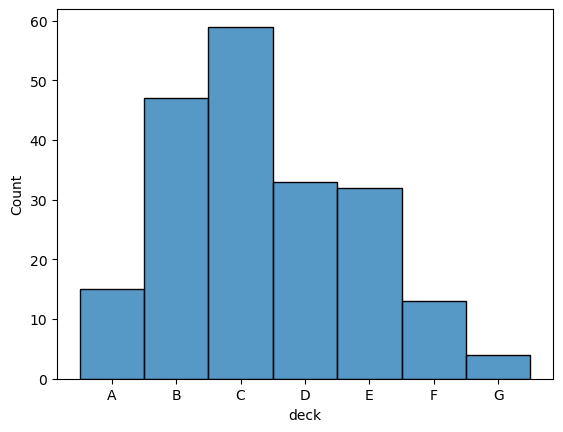

In [73]:
sns.histplot(x= data['deck'])

<Axes: xlabel='age', ylabel='Density'>

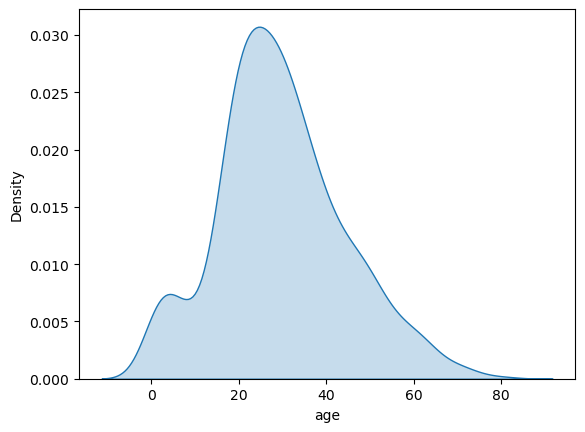

In [75]:

sns.kdeplot(data['age'], fill=True)

In [77]:
data['age']= data['age'].fillna(data['age'].mean())

In [79]:
data['deck'] = data['deck'].fillna('C')

In [81]:
data = data.dropna(subset = ['embarked','embark_town'])

In [83]:
from sklearn.model_selection import ParameterGrid,train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

In [85]:
transformer = ColumnTransformer([
    ('encoder',OneHotEncoder(),['sex','embarked','class','who','deck','embark_town','alone'])
  
],remainder = 'passthrough')

In [87]:
x= data.drop(['survived','alive'],axis = 1)
y = data['survived']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state =10)

In [89]:
x_train_transformed = transformer.fit_transform(x_train)
x_test_transformed = transformer.transform(x_test)


In [103]:
x_train_transformed.shape

(711, 29)

In [91]:
param_grid ={
    'min_samples_leaf' :[2,5,10],
    'min_samples_split':[2,5,10,15],
    'max_depth':[5,8,10]
    
}
results =  []
for param in ParameterGrid(param_grid):

    dt = DecisionTreeClassifier(
        **param,random_state =42
    )
    dt.fit(x_train_transformed,y_train)
    
    y_pred = dt.predict(x_test_transformed)

    accuracy = accuracy_score(y_test, y_pred)
    results.append([ 
        param['min_samples_leaf'],
        param['min_samples_split'],
        param['max_depth'], accuracy  ])

results


[[2, 2, 5, 0.8539325842696629],
 [2, 5, 5, 0.8539325842696629],
 [2, 10, 5, 0.8539325842696629],
 [2, 15, 5, 0.8539325842696629],
 [5, 2, 5, 0.8539325842696629],
 [5, 5, 5, 0.8539325842696629],
 [5, 10, 5, 0.8539325842696629],
 [5, 15, 5, 0.8539325842696629],
 [10, 2, 5, 0.8370786516853933],
 [10, 5, 5, 0.8370786516853933],
 [10, 10, 5, 0.8370786516853933],
 [10, 15, 5, 0.8370786516853933],
 [2, 2, 8, 0.8314606741573034],
 [2, 5, 8, 0.8314606741573034],
 [2, 10, 8, 0.8258426966292135],
 [2, 15, 8, 0.8258426966292135],
 [5, 2, 8, 0.8370786516853933],
 [5, 5, 8, 0.8370786516853933],
 [5, 10, 8, 0.8370786516853933],
 [5, 15, 8, 0.8314606741573034],
 [10, 2, 8, 0.8426966292134831],
 [10, 5, 8, 0.8426966292134831],
 [10, 10, 8, 0.8426966292134831],
 [10, 15, 8, 0.8426966292134831],
 [2, 2, 10, 0.8314606741573034],
 [2, 5, 10, 0.8370786516853933],
 [2, 10, 10, 0.8258426966292135],
 [2, 15, 10, 0.8258426966292135],
 [5, 2, 10, 0.8370786516853933],
 [5, 5, 10, 0.8370786516853933],
 [5, 10, 10,

In [93]:
path = dt.cost_complexity_pruning_path(x_train_transformed,y_train)

In [95]:
path.ccp_alphas

array([0.00000000e+00, 1.27860887e-04, 1.33646448e-04, 1.81599521e-04,
       4.41204180e-04, 5.34623009e-04, 5.79080106e-04, 5.87843399e-04,
       6.25097672e-04, 7.53430907e-04, 8.05852515e-04, 1.04654286e-03,
       1.25998950e-03, 1.31166509e-03, 1.85098771e-03, 2.02228583e-03,
       2.08839449e-03, 2.10309141e-03, 2.15159669e-03, 2.85694038e-03,
       4.21403587e-03, 4.27215190e-03, 1.04008247e-02, 1.96322522e-02,
       4.27598652e-02, 1.43736390e-01])

In [97]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[103  12]
 [ 16  47]]


In [99]:
dt.feature_importances_

array([0.        , 0.        , 0.00458046, 0.        , 0.        ,
       0.03772479, 0.        , 0.00277987, 0.        , 0.52134575,
       0.        , 0.        , 0.        , 0.00816224, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.0134734 , 0.        , 0.        , 0.15509416, 0.09524283,
       0.        , 0.        , 0.16159649, 0.        ])